In [127]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [81]:
df0 = pd.read_csv(r'E:\EX\STD Vatsal Mavani\archive\data\data_by_artist.csv')

In [82]:
df1 = pd.read_csv(r'E:\EX\STD Vatsal Mavani\archive\data\data_by_genres.csv')

In [83]:
df2 = pd.read_csv(r'E:\EX\STD Vatsal Mavani\archive\data\data_by_year.csv')

In [84]:
df3 = pd.read_csv(r'E:\EX\STD Vatsal Mavani\archive\data\data_w_genres.csv')

In [85]:
df4 = pd.read_csv(r'E:\EX\STD Vatsal Mavani\archive\data\data.csv')

In [86]:
df3['artists'].dtypes, df4['artists'].dtypes

(<StringDtype(storage='python', na_value=nan)>,
 <StringDtype(storage='python', na_value=nan)>)

In [87]:
print("Bên bài hát:", df4['artists'].iloc[0])
print("Bên thể loại:", df3['artists'].iloc[0])

Bên bài hát: ['Sergei Rachmaninoff', 'James Levine', 'Berliner Philharmoniker']
Bên thể loại: "Cats" 1981 Original London Cast


In [88]:
df3[df3['artists'] == 311]

,genres,artists,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key,mode,count


In [89]:
# Xóa dấu ngoặc vuông và dấu nháy để chỉ còn tên nghệ sĩ trơn
df4['artists_clean'] = df4['artists'].str.replace(r"[\[\]']", "", regex=True).str.strip()
df3['artists_clean'] = df3['artists'].str.replace(r"[\[\]']", "", regex=True).str.strip()

# Gộp tất cả các dòng trùng tên nghệ sĩ, nối các chuỗi thể loại lại với nhau
df3_combined = df3.groupby('artists_clean')['genres'].apply(lambda x: ', '.join(x)).reset_index()

# Bây giờ mới tạo từ điển từ bộ đã gộp
genre_dict = df3_combined.set_index('artists_clean')['genres']

# Map vào bộ chính
df4['track_genre'] = df4['artists_clean'].map(genre_dict)

In [90]:
a1 = df4['track_genre'].isna().sum()
a2 = df4.shape[0]
a2 - a1

np.int64(134782)

In [91]:
dft = df4[df4['track_genre'].notna()]
df = dft[dft['track_genre'] != '[]']
df.shape, dft[dft['track_genre'] == '[]'].shape, dft.shape

((121076, 21), (13706, 21), (134782, 21))

In [92]:
df['year'].min(), df['year'].max()

(np.int64(1921), np.int64(2020))

In [93]:
df[(df['track_genre'].str.contains('j-pop')) | (df['track_genre'].str.contains('anime'))].shape

(334, 21)

In [94]:
len(set(df['track_genre']))

8737

In [95]:
japan_pattern = 'j-pop|j-rock|japanese|anime|vocaloid|visual kei|city pop|shibuya-kei|enka|kayokyoku|okinawan pop|video game music|otacore|denpa-kei|jazz|big band|swing|fusion|disco|techno|synthpop|lo-fi'

df_japan = df4[df4['track_genre'].str.contains(japan_pattern, case=False, na=False)].copy()

In [96]:
df_japan['year'].dtypes

dtype('int64')

In [97]:
dfWar = df_japan[(df_japan['year'] >= 1921) & (1945 >= df_japan['year'])]

In [98]:
dfDispersal = df_japan[(df_japan['year'] >= 1946) & (df_japan['year'] <= 1959)]

In [99]:
dfRapidGrowth = df_japan[(df_japan['year'] >= 1960) & (df_japan['year'] <= 1989)]

In [100]:
dfLostDecade = df_japan[(df_japan['year'] >= 1990) & (df_japan['year'] <= 2010)]

In [101]:
dfTransitional = df_japan[(df_japan['year'] >= 2011) & (df_japan['year'] <= 2020)]

In [102]:
dfTransitional.shape

(645, 21)

<Axes: xlabel='year', ylabel='popularity'>

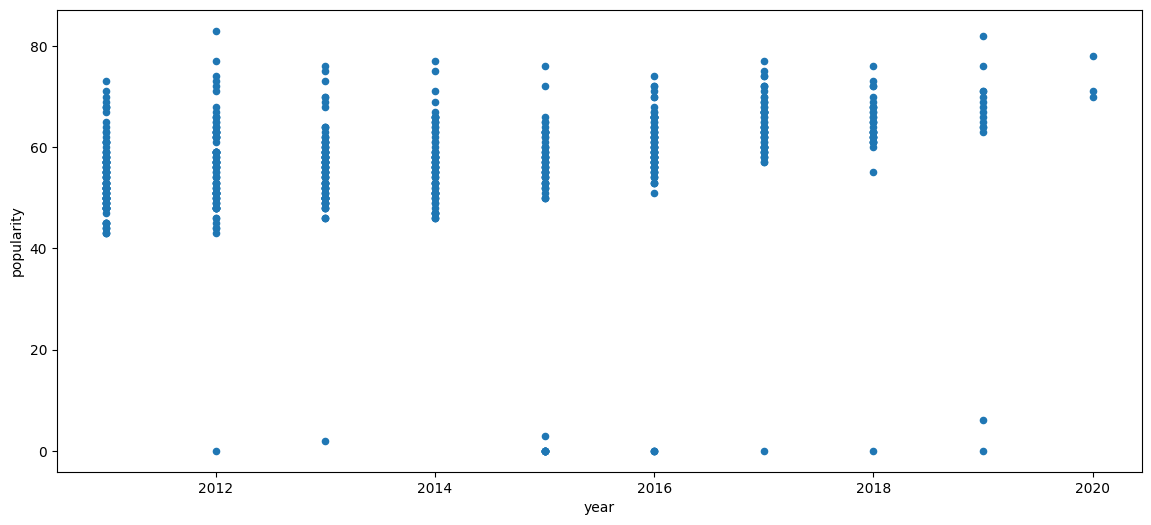

In [104]:
dfTransitional.plot(kind = 'scatter', x = 'year', y = 'popularity', figsize = (14, 6))

In [105]:
dfTransitional['duration_ms'].head()

17814    241440
17862    206507
17863    343253
17864    119787
17865    206640
Name: duration_ms, dtype: int64

<Axes: xlabel='duration_ms', ylabel='popularity'>

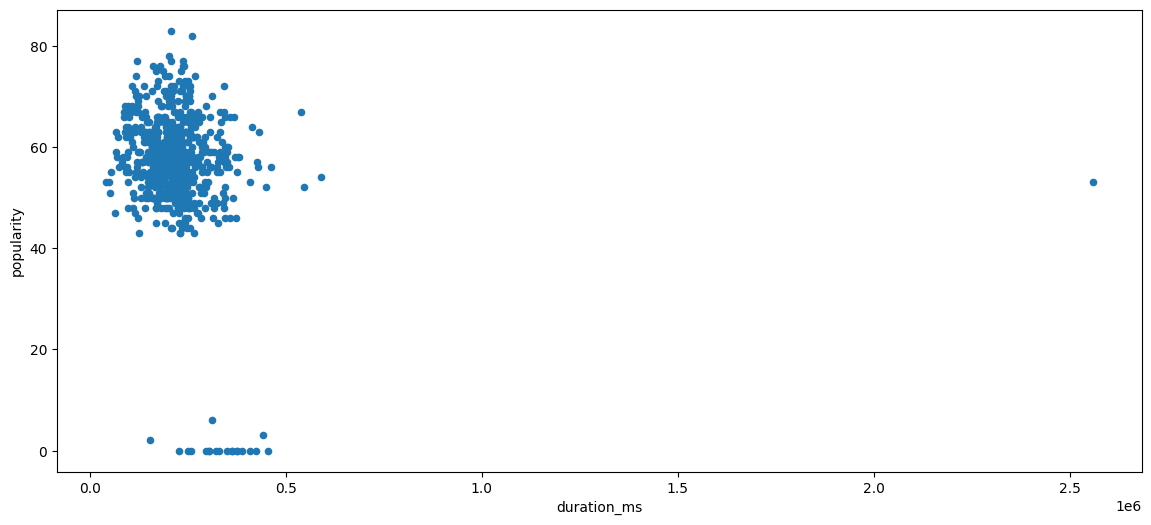

In [106]:
dfTransitional.plot(kind = 'scatter', x = 'duration_ms', y = 'popularity', figsize = (14, 6))

<Axes: xlabel='instrumentalness', ylabel='popularity'>

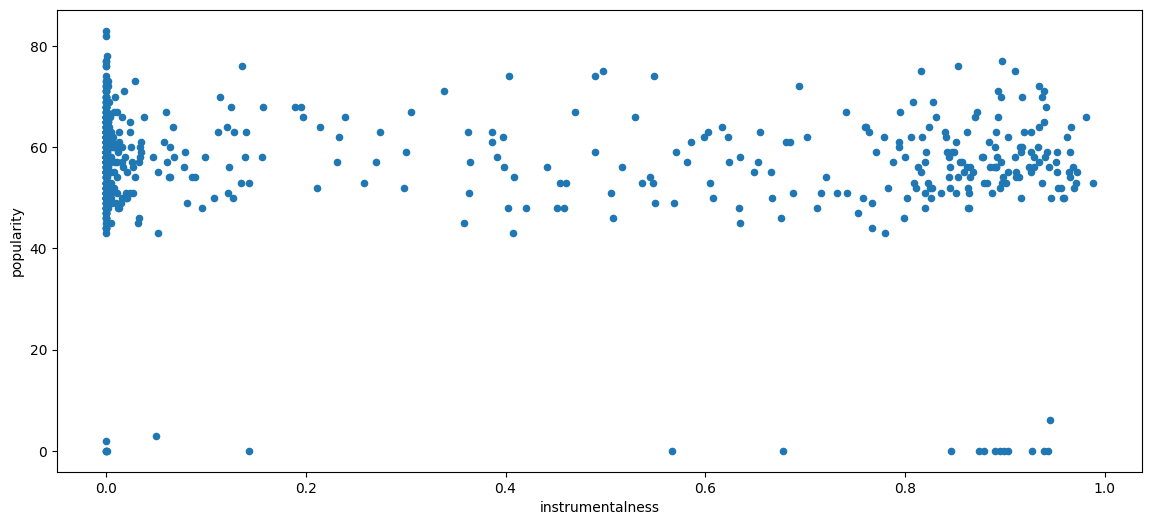

In [107]:
dfTransitional.plot(kind = 'scatter', x = 'instrumentalness', y = 'popularity', figsize = (14, 6))

In [110]:
dfTransitional.corr(numeric_only = True)['popularity'].sort_values() 

duration_ms        -0.183239
instrumentalness   -0.149406
explicit           -0.142726
energy             -0.104147
speechiness        -0.088180
tempo              -0.064388
danceability       -0.017017
liveness            0.005102
loudness            0.014426
key                 0.027947
mode                0.066129
valence             0.103291
acousticness        0.111536
year                0.186350
popularity          1.000000
Name: popularity, dtype: float64

In [118]:
dfTransitional.shape

(645, 21)

In [116]:
y = dfTransitional['popularity'].values
type(y)

numpy.ndarray

In [117]:
lx = ['year', 'duration_ms', 'instrumentalness', 'explicit']
X = dfTransitional[lx].values
type(X)

numpy.ndarray

In [114]:
import sklearn

In [119]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size = .10, random_state = 42)

In [128]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [133]:
import numpy as np
import sys

class LinearRegression:

    def __init__(self, step = 0.01, loops = 1000):
        self.step = step
        self.loops = loops
        self.weights = None
        self.bias = None
    
    def fit(self, X: np.ndarray, y: np.ndarray):
        rowX, coX = X.shape[0], X.shape[1]
        self.weights = np.zeros(coX)
        self.bias = 0
        optimatD = sys.float_info.max

        for i in range(self.loops):
            yPre = np.dot(X, self.weights) + self.bias
            deltaBias = self.step * (1 / rowX) * np.sum(yPre - y)
            deltaWeight = (yPre - y)
            
            self.bias = self.bias - deltaBias
            self.weights = self.weights - self.step * (1 / rowX) * np.dot(X.T, deltaWeight)

            Mean = np.mean((yPre - y)**2)
            optimatD = min(Mean, optimatD)

            print("Error: ",i, Mean)

        yPre = np.dot(X, self.weights) + self.bias
        Mean = np.mean((yPre - y)**2)
        optimatD = min(Mean, optimatD)
        print()
        print('optimatD is:', optimatD)
        print()
    
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [134]:
model = LinearRegression()

model.fit(X_train, y_train)

y_predict = model.predict(X_test)

for i in range(len(y_test)):
    print('predict :', y_predict[i], ' test: ', y_test[i])

Error:  0 3353.8206896551724
Error:  1 3289.5883292973376
Error:  2 3226.6336485714774
Error:  3 3164.9312296157714
Error:  4 3104.4561602747904
Error:  5 3045.184024037245
Error:  6 2987.0908901739685
Error:  7 2930.1533040721347
Error:  8 2874.348277761821
Error:  9 2819.653280631078
Error:  10 2766.0462303257605
Error:  11 2713.5054838304395
Error:  12 2662.0098287267933
Error:  13 2611.538474625946
Error:  14 2562.07104477129
Error:  15 2513.5875678084026
Error:  16 2466.0684697187344
Error:  17 2419.494565913794
Error:  18 2373.8470534866606
Error:  19 2329.107503617672
Error:  20 2285.257854131235
Error:  21 2242.280402200736
Error:  22 2200.1577971986176
Error:  23 2158.8730336887306
Error:  24 2118.4094445581204
Error:  25 2078.7506942854825
Error:  26 2039.8807723435702
Error:  27 2001.7839867328719
Error:  28 1964.4449576439697
Error:  29 1927.8486112459948
Error:  30 1891.9801735986932
Error:  31 1856.825164685619
Error:  32 1822.3693925660673
Error:  33 1788.598947643363
Er